In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import norm, pearsonr, uniform, ks_2samp, chi2

# Математическая статистика
# Задание 1 Python, практическое
#Задача 1
Создайте три выборки $X_1$, $X_2$, $X_3$ объема $N$ из нормального распределения с матожиданием 0 и дисперсией $\theta^2$ (${\cal N}(0, \theta)$), постройте статистику $T =\sqrt{ X_1^2+ X_2^2 + X_3^2}$.

1. Постройте на общем графике эмпирическую функцию распределения $(T/\theta)^2$ и функцию распределения хи квадрат с тремя степенями свободы.

2. Постройте на общем графике выборочное среднее функции $\frac{I_{|x|\le T}}{2T}$ (среднее в каждой точке $x$ от 0 до $3\theta$, можно взять 31 точку) и функцию распределения нормальной случайной величины с матожиданием 0 и дисперсией $\theta^2$.

In [ ]:
rng = 12345
np.random.seed(rng)

N = 10000
theta = 1.0

In [ ]:
# Генерируем три выборки из N(0, θ^2)
X1 = np.random.normal(0, theta, N)
X2 = np.random.normal(0, theta, N)
X3 = np.random.normal(0, theta, N)

T = np.sqrt(X1**2 + X2**2 + X3**2)

In [ ]:
T_squared_norm = (T/theta)**2

# Эмпирическая функция распределения
sorted_data = np.sort(T_squared_norm)
ecdf_y = np.arange(1, N + 1) / N

# Теоретическая функция распределения хи-квадрат со степенью свободы 3
x_chi2 = np.linspace(0, max(T_squared_norm), 500)
chi2_cdf = chi2.cdf(x_chi2, df=3)

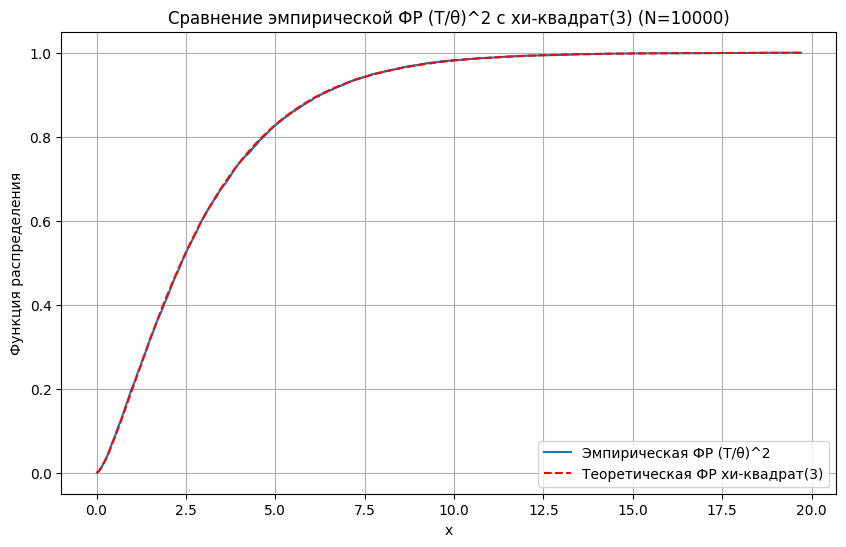

In [ ]:
plt.figure(figsize=(10, 6))
plt.step(sorted_data, ecdf_y, label='Эмпирическая ФР (T/θ)^2')
plt.plot(x_chi2, chi2_cdf, 'r--', label='Теоретическая ФР хи-квадрат(3)')
plt.xlabel('x')
plt.ylabel('Функция распределения')
plt.title(f'Сравнение эмпирической ФР (T/θ)^2 с хи-квадрат(3) (N={N})')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Определяем сетку x от 0 до 3θ
x_points = np.linspace(0, 3 * theta, 31)

# Функция p_T(x) = I(|x| <= T) / (2T)
def p_T(x, T):
    indicator = (np.abs(x) <= T).astype(float)
    return indicator / (2 * T + 1e-10)

In [ ]:
# Вычисляем оценку плотности для каждой точки x
# Усредняем по всем значениям T из выборки
p_estimate = np.zeros(len(x_points))

for i, x in enumerate(x_points):
    p_estimate[i] = np.mean(p_T(x, T))

# Теоретическая плотность N(0, θ^2)
theoretical_pdf = norm.pdf(x_points, loc=0, scale=theta)

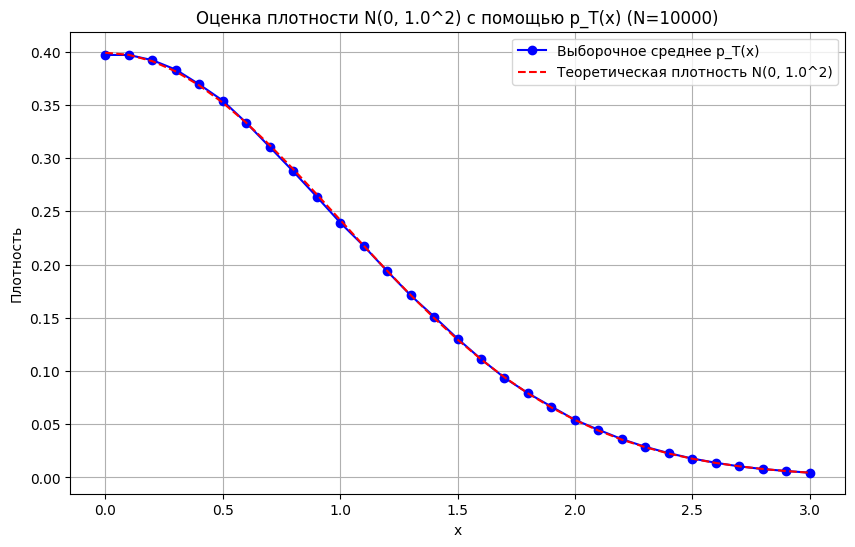

In [ ]:
# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(x_points, p_estimate, 'bo-', label='Выборочное среднее p_T(x)')
plt.plot(x_points, theoretical_pdf, 'r--', label=f'Теоретическая плотность N(0, {theta}^2)')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'Оценка плотности N(0, {theta}^2) с помощью p_T(x) (N={N})')
plt.legend()
plt.grid()
plt.show()

#Задача 2

Известно, что $X \sim {\cal N}(0,1)$ имеет стандартное нормальное распределение. Необходимо найти ковариацию $Cov(X^3 + X^2, \; X + X^4)$ и коэффициент корреляции, сделать вывод.

In [ ]:
N = 100000
X = np.random.normal(0, 1, N)

# Вычисляем функции от X
U = X**3 + X**2   # U = X^3 + X^2
V = X + X**4      # V = X + X^4

In [ ]:
# Mатожидания
mean_U = np.mean(U)
mean_V = np.mean(V)
print(f"Среднее X^3 + X^2: {mean_U:.4f}")
print(f"Среднее X + X^4:   {mean_V:.4f}")

# Дисперсии
var_U = np.var(U)
var_V = np.var(V)
print(f"Дисперсия X^3 + X^2: {var_U:.4f}")
print(f"Дисперсия X + X^4:   {var_V:.4f}")

# Ковариация (ручной расчет) = E[UV] - E[U]E[V]
cov_manual = np.mean(U * V) - mean_U * mean_V
print(f"Ковариация (ручной расчет): {cov_manual:.4f}")

# Коэффициент корреляции (ручной расчет)
corr_manual = cov_manual / np.sqrt(var_U * var_V)
print(f"Коэффициент корреляции (ручной расчет): {corr_manual:.4f}")

Среднее X^3 + X^2: 1.0152
Среднее X + X^4:   3.0235
Дисперсия X^3 + X^2: 17.4070
Дисперсия X + X^4:   98.7299
Ковариация (ручной расчет): 16.0551
Коэффициент корреляции (ручной расчет): 0.3873


In [ ]:
# Используем scipy.stats.pearsonr для корреляции
corr_scipy, p_value = pearsonr(U, V)
print(f"Коэффициент корреляции (scipy.stats.pearsonr): {corr_scipy:.6f}")

Коэффициент корреляции (scipy.stats.pearsonr): 0.387280


Между случайными величинами $U = X^3 + X^2$ и $V = X + X^4$ существует умеренная положительная связь.

#Задача 3
**Симуляция, метод Монте Карло**

Пусть $U \sim \text{Uniform}(0,1)$ — случайная величина, равномерно распределенная на отрезке $[0; 1]$. Рассмотрим две тройки случайных величин:

\begin{align*}
\text{Тройка 1:} & \quad X_1 = \tan\left(\frac{\pi U}{2}\right), \quad Y_1 = \tan\left(\frac{\pi U}{2}\right), \quad Z_1 = -2 \tan\left(\frac{\pi U}{2}\right) \\
\text{Тройка 2:} & \quad X_2 = \tan\left(\frac{\pi U}{2}\right), \quad Y_2 = \tan\left(\frac{\pi (1-U)}{2}\right), \quad Z_2 = -2 \tan\left(\frac{\pi |2U - 1|}{2}\right)
\end{align*}
**С помощью симуляции (Монте Карло)**

а) Найти $\mathbb{E}(X_1 + Y_1 + Z_1)$

б) Правда ли что одинаково распределены $X_1$ и $X_2$, $Y_1$ и $Y_2$, $Z_1$ и $Z_2$? Визуально сравнить три пары гистограмм и определить (заподозрить?) одинаковость распределения.

в) Найти $\mathbb{E}(X_2 + Y_2 + Z_2)$                                                                                 
г) Построить гистограммы сумм $X_1 + Y_1 + Z_1$ и $X_2 + Y_2 + Z_2$ и на них провести линии среднего. Увидеть, что они разные.

In [ ]:
N = 100000
U = np.random.uniform(0, 1, N)

tan_val = np.tan(np.pi * U / 2)

tan_val = np.tan(np.pi * U / 2)

X1 = tan_val
Y1 = tan_val
Z1 = -2 * tan_val

S1 = X1 + Y1 + Z1

X2 = np.tan(np.pi * U / 2)
Y2 = np.tan(np.pi * (1 - U) / 2)
Z2 = -2 * np.tan(np.pi * np.abs(2*U - 1) / 2)

S2 = X2 + Y2 + Z2

In [ ]:
mean_S1 = np.mean(S1)
mean_S2 = np.mean(S2)

print(f"Выборочное среднее S1 = X1 + Y1 + Z1: {mean_S1:.8f}")
print(f"Выборочное среднее S2 = X2 + Y2 + Z2: {mean_S2:.6f}")

Выборочное среднее S1 = X1 + Y1 + Z1: 0.00000000
Выборочное среднее S2 = X2 + Y2 + Z2: 0.882248


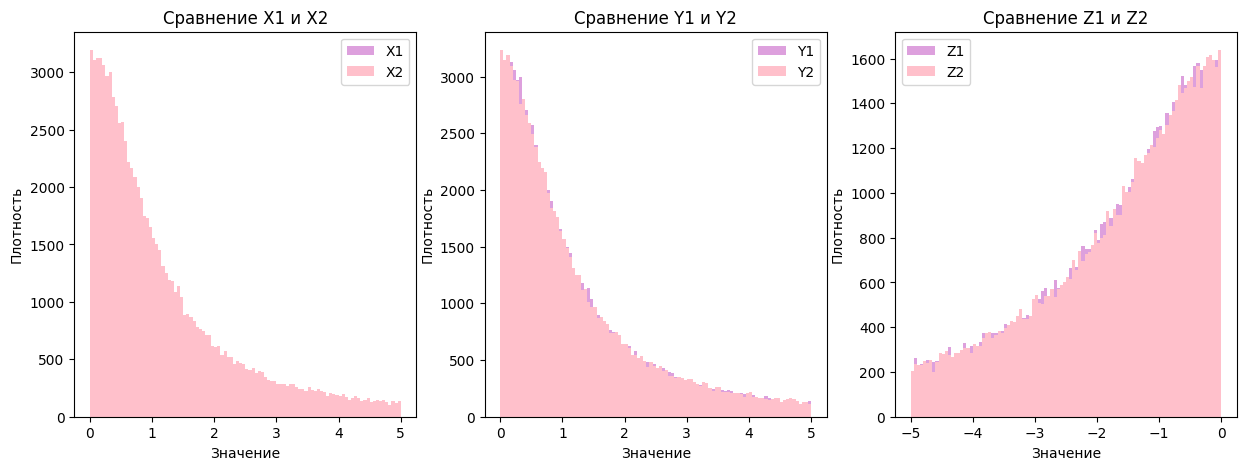

In [ ]:
# Визуальное сравнение гистограмм
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ограничиваем диапазон для лучшей визуализации
xlim = (0, 5)

# 1. Сравнение X1 и X2
ax = axes[0]
ax.hist(X1, bins=100, label='X1', color='plum', range=xlim)
ax.hist(X2, bins=100, label='X2', color='pink', range=xlim)
ax.set_title('Сравнение X1 и X2')
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

# 2. Сравнение Y1 и Y2
ax = axes[1]
ax.hist(Y1, bins=100, label='Y1', color='plum', range=xlim)
ax.hist(Y2, bins=100, label='Y2', color='pink', range=xlim)
ax.set_title('Сравнение Y1 и Y2')
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

# Ограничиваем диапазон для лучшей визуализации
xlim = (-5, 0)

# 3. Сравнение Z1 и Z2
ax = axes[2]
ax.hist(Z1, bins=100, label='Z1', color='plum', range=xlim)
ax.hist(Z2, bins=100, label='Z2', color='pink', range=xlim)
ax.set_title('Сравнение Z1 и Z2')
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()
plt.show()

На основании построенных гистограмм можно сделать следующие выводы: гистограммы для X1 и X2 абсолютно идентичны, объясняется тем, что обе величины определяются одной и той же формулой; гистограммы Y1 и Y2 получились очень похожими, однако мы видим, что Y2 выходит за пределы X1, это объясняется разными параметрами масштаба; гистограммы для Z1 и Z2 в целом тоже довольно схожи, но график Z1 более выраженно выходит за график Z2 из-за разного распределения аргументов в формуле.

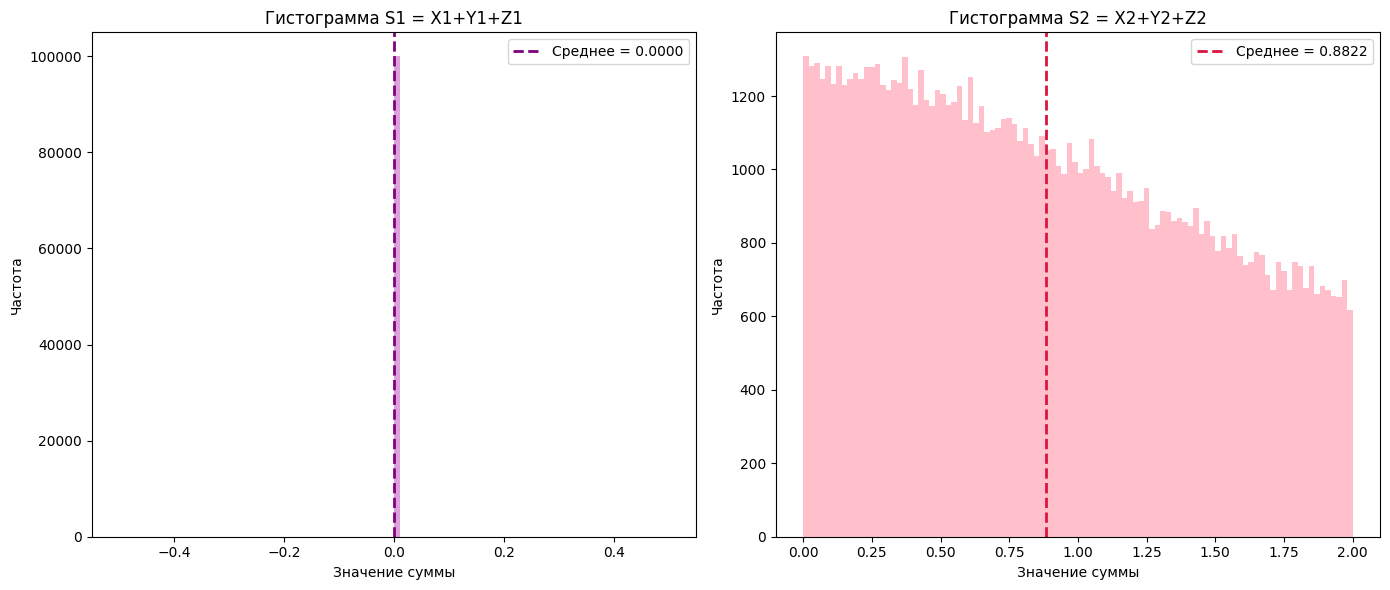

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: S1
axes[0].hist(S1, bins=100, color='plum')
axes[0].axvline(mean_S1, color='purple', linestyle='--', linewidth=2, label=f'Среднее = {mean_S1:.4f}')
axes[0].set_xlabel('Значение суммы')
axes[0].set_ylabel('Частота')
axes[0].set_title('Гистограмма S1 = X1+Y1+Z1')
axes[0].legend()

# График 2: S2
axes[1].hist(S2, bins=100, color='pink')
axes[1].axvline(mean_S2, color='crimson', linestyle='--', linewidth=2, label=f'Среднее = {mean_S2:.4f}')
axes[1].set_xlabel('Значение суммы')
axes[1].set_ylabel('Частота')
axes[1].set_title('Гистограмма S2 = X2+Y2+Z2')
axes[1].legend()

plt.tight_layout()
plt.show()

Гистограммы абсолютно разные, это говорит о том, что, несмотря на схожесть попарных распределений X, Y, Z в отдельных тройках, суммы ведут себя по-разному. Средние значения сумм тоже отличаются.